In [1]:
# Preparacion del notebook

import sys
sys.path.append("..")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import cargar_enemdu, mediana_ponderada
from src.features import agregar_variables

df = agregar_variables(cargar_enemdu())
os.makedirs("../reports/figures", exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
FUENTE = "Fuente: INEC, ENEMDU I Trimestre 2026. Cálculos propios, ponderados con fexp."

In [2]:
# Comprobacion de la funcion

ing = df[df["condact"].between(1, 6) & (df["ingrl"] > 0)]
print(ing.groupby("sexo").apply(lambda s: mediana_ponderada(s["ingrl"], s["fexp"])))

sexo
Hombre    430.0
Mujer     350.0
dtype: float64


condact
Empleo adecuado                   35.7
Subempleo                         18.4
Otro empleo no pleno              32.6
No remunerado / no clasificado     9.9
Desempleo                          3.4
Name: fexp, dtype: float64


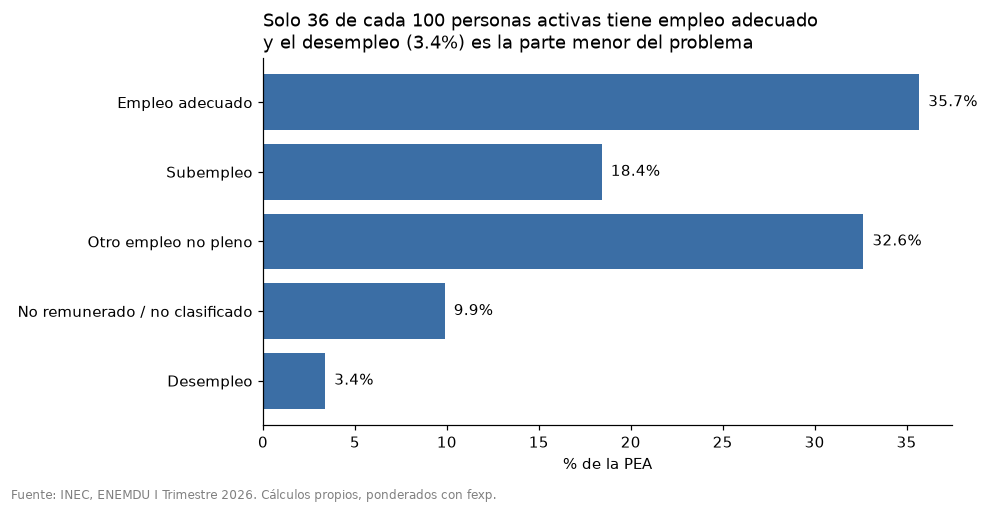

In [3]:
# Grafico 1: de que esta hecha la PEA

mapa = {1: "Empleo adecuado", 2: "Subempleo", 3: "Subempleo",
        4: "Otro empleo no pleno",
        5: "No remunerado / no clasificado", 6: "No remunerado / no clasificado",
        7: "Desempleo", 8: "Desempleo"}
orden = ["Empleo adecuado", "Subempleo", "Otro empleo no pleno",
         "No remunerado / no clasificado", "Desempleo"]

pea = df[df["condact"].between(1, 8)]
comp = pea.groupby(pea["condact"].map(mapa))["fexp"].sum()
comp = (100 * comp / comp.sum()).reindex(orden)
print(comp.round(1))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(comp.index[::-1], comp.values[::-1], color="#3b6ea5")
for y, v in enumerate(comp.values[::-1]):
    ax.text(v + 0.5, y, f"{v:.1f}%", va="center")
ax.set_xlabel("% de la PEA")
ax.set_title(f"Solo {comp['Empleo adecuado']:.0f} de cada 100 personas activas tiene empleo adecuado\n"
             f"y el desempleo ({comp['Desempleo']:.1f}%) es la parte menor del problema", loc="left")
fig.text(0.01, -0.02, FUENTE, fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/01_composicion_pea.png", dpi=150, bbox_inches="tight")

Informalidad nacional: 53.5
sexo    Hombre  Mujer
zona                 
Urbana    44.7   37.2
Rural     73.5   78.9


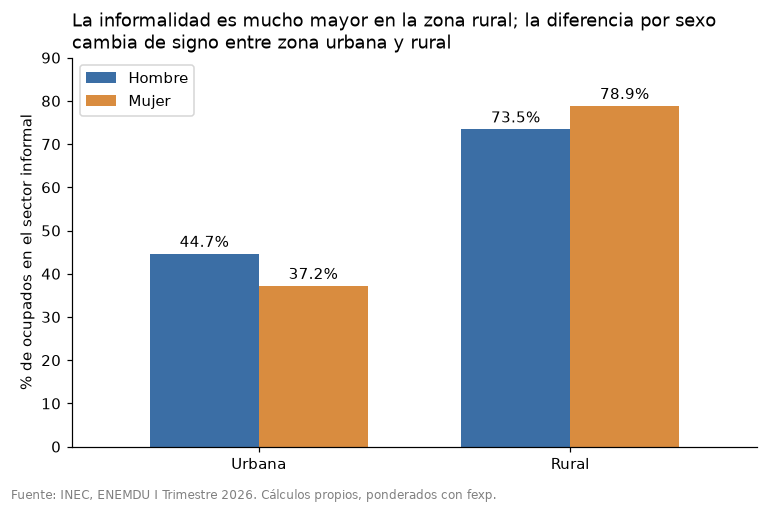

In [4]:
# Informalidad por zona y sexo

oc = df[df["informal"].notna()].copy()
oc["w_inf"] = oc["informal"] * oc["fexp"]

print("Informalidad nacional:", round(100 * oc["w_inf"].sum() / oc["fexp"].sum(), 1))   # debe dar 53.5

g = oc.groupby(["zona", "sexo"])[["w_inf", "fexp"]].sum()
res = (100 * g["w_inf"] / g["fexp"]).unstack().reindex(["Urbana", "Rural"])
print(res.round(1))

ax = res.plot(kind="bar", figsize=(7, 4.5), color=["#3b6ea5", "#d98c3f"], rot=0, width=0.7)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2)
ax.set_ylabel("% de ocupados en el sector informal")
ax.set_xlabel("")
ax.set_ylim(0, 90)
ax.set_title("La informalidad es mucho mayor en la zona rural; la diferencia por sexo\n"
             "cambia de signo entre zona urbana y rural", loc="left")
ax.legend(title="")
plt.gcf().text(0.01, -0.02, FUENTE, fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/02_informalidad_zona_sexo.png", dpi=150, bbox_inches="tight")

sexo
Hombre    430.0
Mujer     350.0
dtype: float64 
razón: 0.814


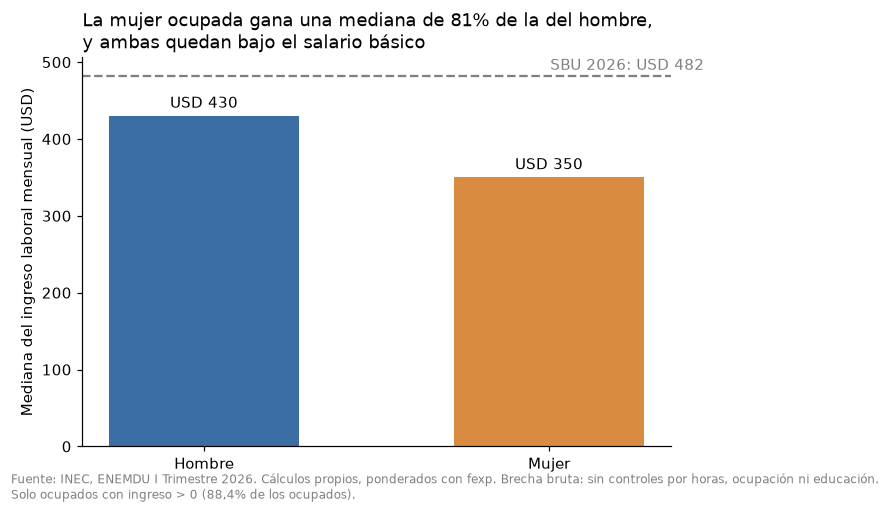

In [5]:
# Brecha de ingresos por sexo

SBU = 482
ing = df[df["condact"].between(1, 6) & (df["ingrl"] > 0)]
med = ing.groupby("sexo").apply(lambda s: mediana_ponderada(s["ingrl"], s["fexp"]))
ratio = med["Mujer"] / med["Hombre"]
print(med, f"\nrazón: {ratio:.3f}")

fig, ax = plt.subplots(figsize=(6.5, 4.5))
barras = ax.bar(med.index, med.values, color=["#3b6ea5", "#d98c3f"], width=0.55)
ax.bar_label(barras, fmt="USD %.0f", padding=3)
ax.axhline(SBU, color="gray", linestyle="--")
ax.text(1.45, SBU + 8, f"SBU 2026: USD {SBU}", ha="right", color="gray")
ax.set_ylabel("Mediana del ingreso laboral mensual (USD)")
ax.set_title(f"La mujer ocupada gana una mediana de {ratio:.0%} de la del hombre,\n"
             "y ambas quedan bajo el salario básico", loc="left")
fig.text(0.01, -0.02, FUENTE + " Brecha bruta: sin controles por horas, ocupación ni educación.\n"
         "Solo ocupados con ingreso > 0 (88,4% de los ocupados).", fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/03_brecha_ingreso_sexo.png", dpi=150, bbox_inches="tight")

       Empleo adecuado  Desempleo  n (sin ponderar)
15-24             18.9        8.5            5394.0
25-34             44.9        5.2            8946.0
35-44             43.0        2.0            8596.0
45-54             41.2        1.6            8286.0
55-64             32.8        0.9            6351.0
65+               12.9        0.7            4107.0


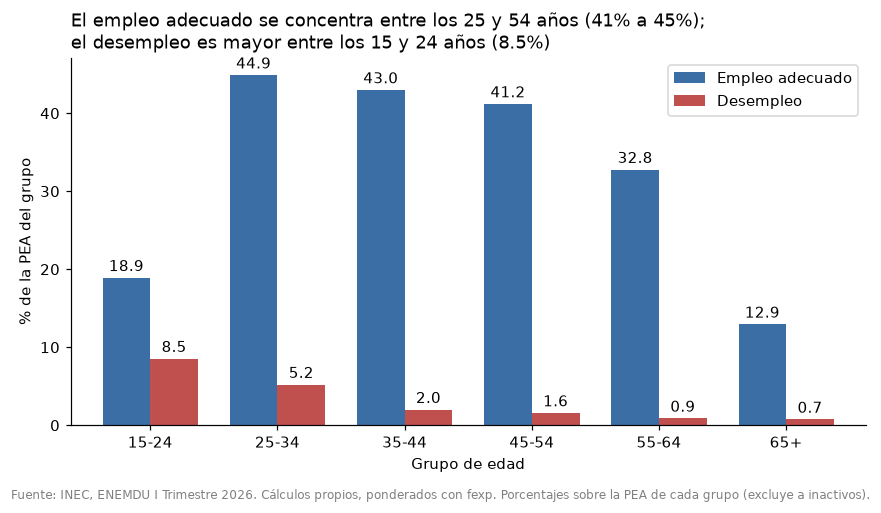

In [6]:
# Indicadores por grupo de edad

pea = df[df["condact"].between(1, 8)]

filas = {}
for g, s in pea.groupby("grupo_edad", observed=True):
    total = s["fexp"].sum()
    filas[g] = {
        "Empleo adecuado": 100 * s.loc[s["condact"] == 1, "fexp"].sum() / total,
        "Desempleo": 100 * s.loc[s["condact"].isin([7, 8]), "fexp"].sum() / total,
        "n (sin ponderar)": len(s),
    }
edad = pd.DataFrame(filas).T
print(edad.round(1))

ax = edad[["Empleo adecuado", "Desempleo"]].plot(kind="bar", figsize=(8, 4.5),
                                                  color=["#3b6ea5", "#c0504d"], rot=0, width=0.75)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", padding=2)
ax.set_ylabel("% de la PEA del grupo")
ax.set_xlabel("Grupo de edad")
ax.set_title("El empleo adecuado se concentra entre los 25 y 54 años (41% a 45%);\n"
             f"el desempleo es mayor entre los 15 y 24 años ({edad['Desempleo'].iloc[0]:.1f}%)",
             loc="left")
plt.gcf().text(0.01, -0.02, FUENTE + " Porcentajes sobre la PEA de cada grupo (excluye a inactivos).",
               fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/04_indicadores_edad.png", dpi=150, bbox_inches="tight")

          % informal      n
nivel                      
Ninguno         90.0    842
Básica          74.6  12766
Media           48.3  14358
Superior        19.6  11909


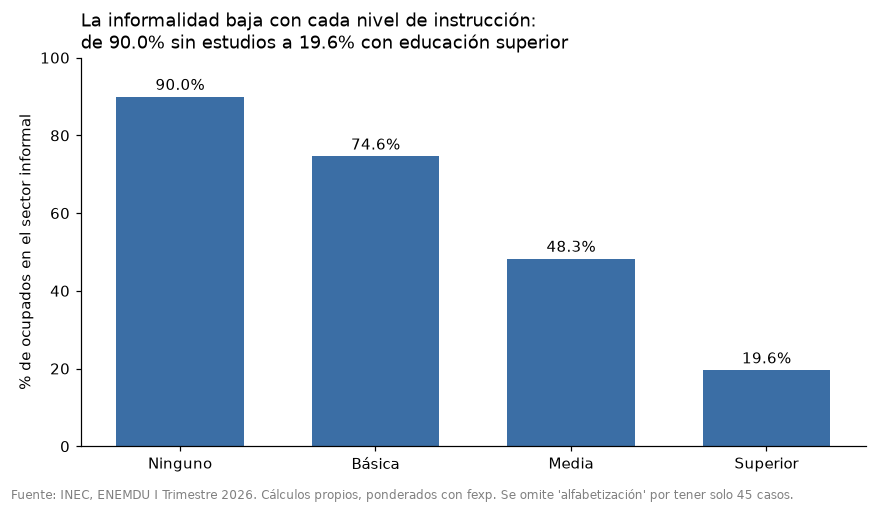

In [7]:
# Informalidad por nivel de instruccion

niveles = {1: "Ninguno", 3: "Básica", 4: "Media", 5: "Superior"}   # se omite alfabetización (n = 45)

oc = df[df["informal"].notna()].copy()
oc["nivel"] = oc["nnivins"].map(niveles)     # el código 2 queda como NaN y se excluye
oc["w_inf"] = oc["informal"] * oc["fexp"]

g = oc.groupby("nivel")[["w_inf", "fexp"]].sum()
g["% informal"] = 100 * g["w_inf"] / g["fexp"]
g["n"] = oc.groupby("nivel").size()
g = g.reindex(list(niveles.values()))
print(g[["% informal", "n"]].round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(g.index, g["% informal"], color="#3b6ea5", width=0.65)
ax.bar_label(barras, fmt="%.1f%%", padding=2)
ax.set_ylabel("% de ocupados en el sector informal")
ax.set_ylim(0, 100)
ax.set_title("La informalidad baja con cada nivel de instrucción:\n"
             f"de {g['% informal'].iloc[0]:.1f}% sin estudios a {g['% informal'].iloc[-1]:.1f}% con educación superior",
             loc="left")
fig.text(0.01, -0.02, FUENTE + " Se omite 'alfabetización' por tener solo 45 casos.",
         fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/05_informalidad_instruccion.png", dpi=150, bbox_inches="tight")

          mediana      n
nivel                   
Ninguno     155.0    618
Básica      270.0  10905
Media       430.0  12699
Superior    663.0  11050


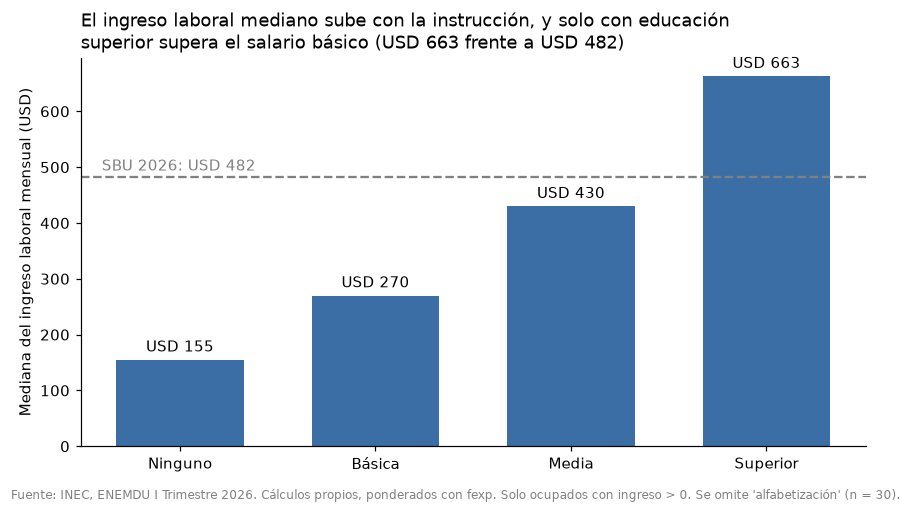

In [8]:
# Ingreso por nivel de instruccion

SBU = 482
ing = df[df["condact"].between(1, 6) & (df["ingrl"] > 0)].copy()
ing["nivel"] = ing["nnivins"].map(niveles)     # niveles definido en la celda anterior

med = ing.groupby("nivel").apply(lambda s: mediana_ponderada(s["ingrl"], s["fexp"]))
n = ing.groupby("nivel").size()
tabla = pd.DataFrame({"mediana": med, "n": n}).reindex(list(niveles.values()))
print(tabla.round(0))

fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(tabla.index, tabla["mediana"], color="#3b6ea5", width=0.65)
ax.bar_label(barras, fmt="USD %.0f", padding=3)
ax.axhline(SBU, color="gray", linestyle="--")
ax.text(-0.4, SBU + 12, f"SBU 2026: USD {SBU}", ha="left", color="gray")
ax.set_ylabel("Mediana del ingreso laboral mensual (USD)")
ax.set_title("El ingreso laboral mediano sube con la instrucción, y solo con educación\n"
             f"superior supera el salario básico (USD {tabla['mediana'].iloc[-1]:.0f} frente a USD {SBU})",
             loc="left")
fig.text(0.01, -0.02, FUENTE + " Solo ocupados con ingreso > 0. Se omite 'alfabetización' (n = 30).",
         fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/06_ingreso_instruccion.png", dpi=150, bbox_inches="tight")

In [9]:
# Comprobacion hipotesis: a edades altas hay mas trabajo independiente y agricola

mapa = {1: "Adecuado", 2: "Subempleo", 3: "Subempleo", 4: "Otro no pleno",
        5: "No remun./no clasif.", 6: "No remun./no clasif.", 7: "Desempleo", 8: "Desempleo"}
tab = pea.groupby(["grupo_edad", pea["condact"].map(mapa)], observed=True)["fexp"].sum().unstack()
print((100 * tab.div(tab.sum(axis=1), axis=0)).round(1))

condact     Adecuado  Desempleo  No remun./no clasif.  Otro no pleno  \
grupo_edad                                                             
15-24           18.9        8.5                  24.7           25.0   
25-34           44.9        5.2                   5.0           26.6   
35-44           43.0        2.0                   8.6           27.5   
45-54           41.2        1.6                   6.5           32.6   
55-64           32.8        0.9                   6.8           41.1   
65+             12.9        0.7                  11.4           65.8   

condact     Subempleo  
grupo_edad             
15-24            22.8  
25-34            18.4  
35-44            18.9  
45-54            18.1  
55-64            18.5  
65+               9.1  


                           % informal  % de ocupados     n
rama                                                      
Organizaciones extraterr.         0.0            0.0    10
Administración pública            0.0            2.8  1501
Hogares (domést.)                 0.4            2.5  1081
Finanzas y seguros                1.6            0.6   404
Enseñanza                         7.8            3.7  1990
Información y comunic.            9.1            0.8   345
Inmobiliarias                     9.6            0.4   141
Agua y alcantarillado            12.2            0.4   178
Salud y serv. sociales           13.1            2.4  1384
Prof. y científicas              15.5            1.8  1090
Minas y canteras                 15.7            0.6   328
Manufactura                      29.5            9.5  4114
Electricidad y gas               30.5            0.2   102
Serv. administrativos            35.8            3.6  1397
Artes y recreación               41.3            0.6   3

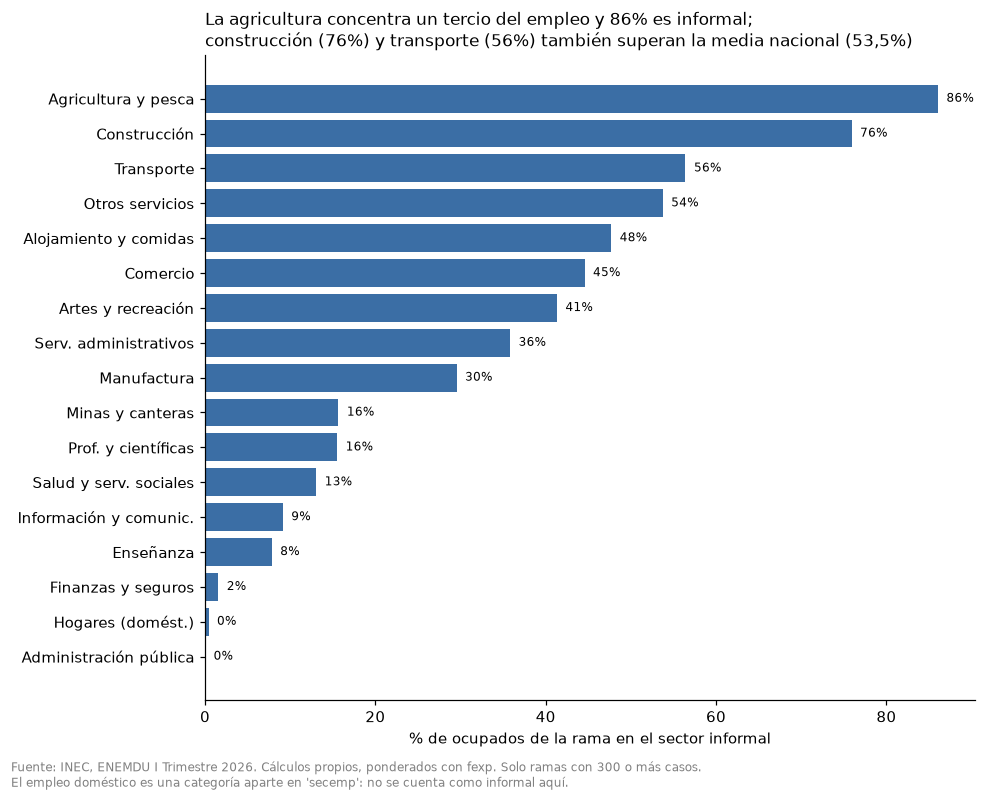

In [15]:
# Informalidad por rama de actividad

ramas = {1: "Agricultura y pesca", 2: "Minas y canteras", 3: "Manufactura", 4: "Electricidad y gas",
         5: "Agua y alcantarillado", 6: "Construcción", 7: "Comercio", 8: "Transporte",
         9: "Alojamiento y comidas", 10: "Información y comunic.", 11: "Finanzas y seguros",
         12: "Inmobiliarias", 13: "Prof. y científicas", 14: "Serv. administrativos",
         15: "Administración pública", 16: "Enseñanza", 17: "Salud y serv. sociales",
         18: "Artes y recreación", 19: "Otros servicios", 20: "Hogares (domést.)",
         21: "Organizaciones extraterr.", 22: "No especificado"}

oc = df[df["informal"].notna()].copy()
oc["rama"] = oc["rama1"].map(ramas)
oc["w_inf"] = oc["informal"] * oc["fexp"]

g = oc.groupby("rama")[["w_inf", "fexp"]].sum()
g["% informal"] = 100 * g["w_inf"] / g["fexp"]
g["% de ocupados"] = 100 * g["fexp"] / g["fexp"].sum()
g["n"] = oc.groupby("rama").size()
g = g.sort_values("% informal")
print(g[["% informal", "% de ocupados", "n"]].round(1))

g_graf = g[g["n"] >= 300]      # umbral propio: ramas con pocos casos se omiten
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(g_graf.index, g_graf["% informal"], color="#3b6ea5")
for y, v in enumerate(g_graf["% informal"]):
    ax.text(v + 1, y, f"{v:.0f}%", va="center", fontsize=8)
ax.set_xlabel("% de ocupados de la rama en el sector informal")
ax.set_title("La agricultura concentra un tercio del empleo y 86% es informal;\n"
             "construcción (76%) y transporte (56%) también superan la media nacional (53,5%)",
             loc="left", fontsize=11)
fig.text(0.01, -0.03, FUENTE + " Solo ramas con 300 o más casos.\n"
         "El empleo doméstico es una categoría aparte en 'secemp': no se cuenta como informal aquí.",
         fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/07_informalidad_rama.png", dpi=150, bbox_inches="tight")

In [16]:
g["% de los informales"] = 100 * g["w_inf"] / g["w_inf"].sum()
print(g[["% informal", "% de ocupados", "% de los informales"]]
      .sort_values("% de los informales", ascending=False).head(6).round(1))

                       % informal  % de ocupados  % de los informales
rama                                                                 
Agricultura y pesca          86.1           32.3                 51.9
Comercio                     44.6           15.8                 13.1
Construcción                 75.9            6.8                  9.6
Transporte                   56.4            6.5                  6.8
Alojamiento y comidas        47.7            6.5                  5.8
Manufactura                  29.5            9.5                  5.2


Excluidos de la PEA ('Otra'): 17
                  Empleo adecuado  Desempleo        n
Indígena                     11.4        1.0   3443.0
Montuvio                     19.7        2.7    715.0
Afrodescendiente             34.2        9.3   1499.0
Blanco                       40.5        2.6    289.0
Mestizo                      41.2        3.7  35717.0


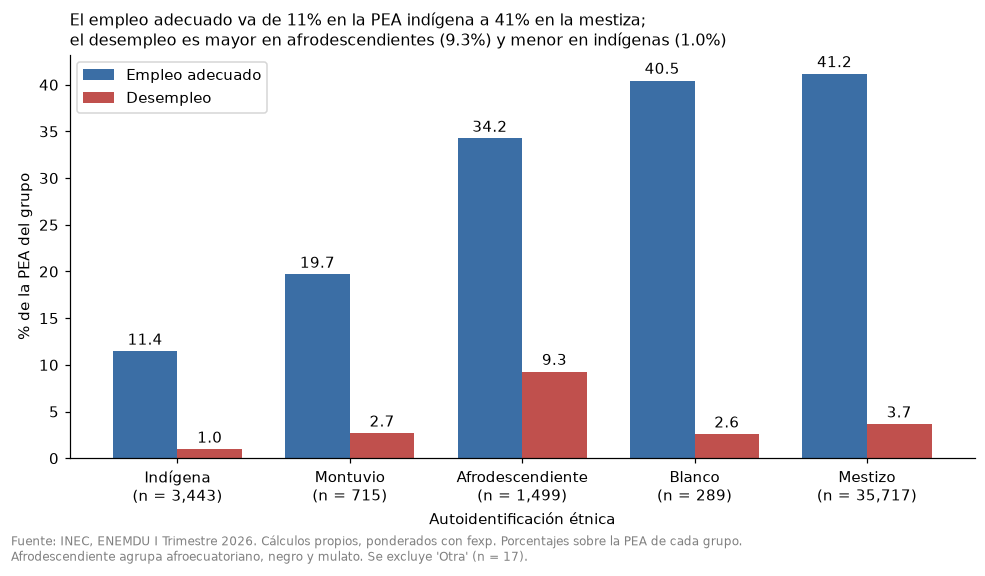

In [23]:
# Desempleo y empleo adecuado por autoidentificación étnica

et = df[df["condact"].between(1, 8)].copy()

agrupar = {"Indígena": "Indígena", "Montuvio": "Montuvio",
           "Afroecuatoriano": "Afrodescendiente", "Negro": "Afrodescendiente",
           "Mulato": "Afrodescendiente", "Blanco": "Blanco", "Mestizo": "Mestizo"}
et["grupo_etnico"] = et["etnia"].map(agrupar)        # "Otra" queda como NaN y se excluye
print("Excluidos de la PEA ('Otra'):", et["grupo_etnico"].isna().sum())   # debe dar 17

filas = {}
for e, s in et.groupby("grupo_etnico"):
    total = s["fexp"].sum()
    filas[e] = {"Empleo adecuado": 100 * s.loc[s["condact"] == 1, "fexp"].sum() / total,
                "Desempleo": 100 * s.loc[s["condact"].isin([7, 8]), "fexp"].sum() / total,
                "n": len(s)}
etnia = pd.DataFrame(filas).T.sort_values("Empleo adecuado")
print(etnia.round(1))

ax = etnia[["Empleo adecuado", "Desempleo"]].plot(
    kind="bar", figsize=(9, 5), color=["#3b6ea5", "#c0504d"], rot=0, width=0.75)
ax.set_xticklabels([f"{e}\n(n = {int(n):,})" for e, n in zip(etnia.index, etnia["n"])], rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", padding=2)
ax.set_ylabel("% de la PEA del grupo")
ax.set_xlabel("Autoidentificación étnica")
ind_ad, mes_ad = etnia.loc["Indígena", "Empleo adecuado"], etnia.loc["Mestizo", "Empleo adecuado"]
ind_d, afro_d = etnia.loc["Indígena", "Desempleo"], etnia.loc["Afrodescendiente", "Desempleo"]
ax.set_title(f"El empleo adecuado va de {ind_ad:.0f}% en la PEA indígena a {mes_ad:.0f}% en la mestiza;\n"
             f"el desempleo es mayor en afrodescendientes ({afro_d:.1f}%) y menor en indígenas ({ind_d:.1f}%)",
             loc="left", fontsize=10.5)
plt.gcf().text(0.01, -0.03, FUENTE + " Porcentajes sobre la PEA de cada grupo.\n"
               "Afrodescendiente agrupa afroecuatoriano, negro y mulato. Se excluye 'Otra' (n = 17).",
               fontsize=8, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/08_indicadores_etnia.png", dpi=150, bbox_inches="tight")

In [18]:
et["rural"] = (et["area"] == 2).astype(int)
print((100 * et.groupby("grupo_etnico").apply(
    lambda s: (s["rural"] * s["fexp"]).sum() / s["fexp"].sum())).round(1))

grupo_etnico
Afrodescendiente    21.6
Blanco              18.0
Indígena            87.8
Mestizo             23.5
Montuvio            56.4
dtype: float64


In [24]:
def pct_adecuado(s):
    return 100 * s.loc[s["condact"] == 1, "fexp"].sum() / s["fexp"].sum()

cruce = (et.groupby(["grupo_etnico", "zona"])
           .apply(lambda s: pd.Series({"% adecuado": pct_adecuado(s), "n": len(s)}))
           .unstack())
print(cruce.round(1))

                 % adecuado              n         
zona                  Rural Urbana   Rural   Urbana
grupo_etnico                                       
Afrodescendiente       17.9   38.7   423.0   1076.0
Blanco                 30.3   42.7    67.0    222.0
Indígena                8.4   33.2  2485.0    958.0
Mestizo                25.3   46.0  8443.0  27274.0
Montuvio               14.8   26.0   396.0    319.0


['15-19', '20-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75+']
PEA sin tramo asignado: 0
sexo   Hombre  Mujer
tramo               
15-19   306.5  162.8
20-24   557.6  290.6
25-29   561.1  391.0
30-34   506.8  434.2
35-39   560.9  435.4
40-44   599.1  472.9
45-49   487.2  355.9
50-54   398.1  277.9
55-59   408.9  251.8
60-64   288.8  196.2
65-69   190.5  105.8
70-74   119.4   65.2
75+     124.2   70.9

Total PEA (miles): {'Hombre': 5109.1, 'Mujer': 3510.7}
tramo
15-19    53.0
20-24    52.0
25-29    70.0
30-34    86.0
35-39    78.0
40-44    79.0
45-49    73.0
50-54    70.0
55-59    62.0
60-64    68.0
65-69    56.0
70-74    55.0
75+      57.0
dtype: float64
Mujeres como % de la PEA: 40.7


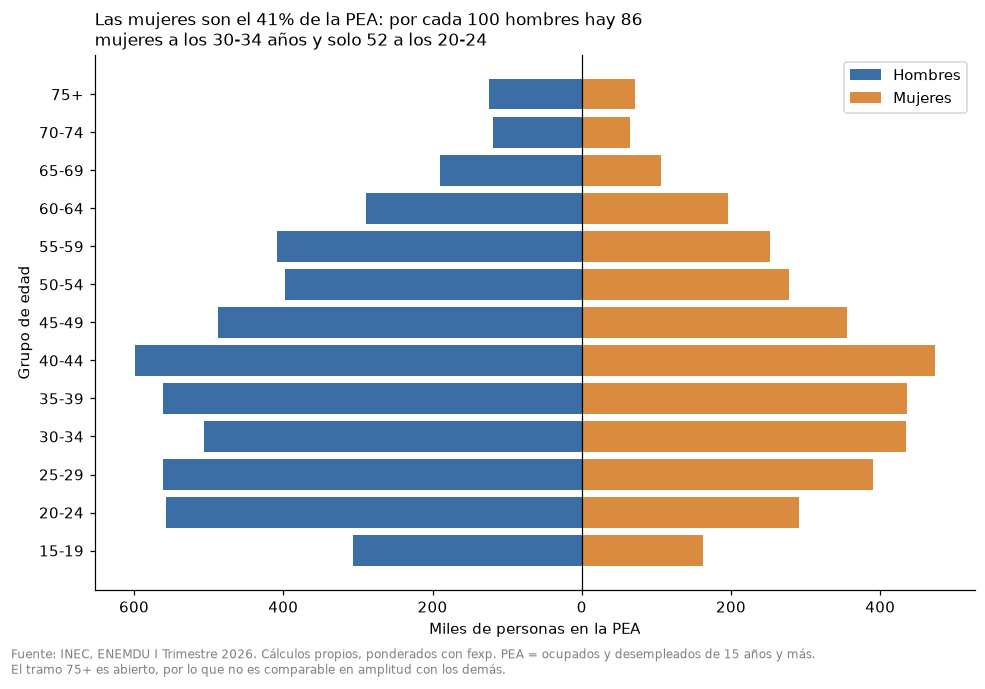

In [25]:
# Piramide PEA

pea = df[df["condact"].between(1, 8)].copy()

bordes = list(range(15, 80, 5)) + [120]                    # 15, 20, ..., 75 y 120
etiquetas = [f"{a}-{a+4}" for a in range(15, 75, 5)] + ["75+"]

pea["tramo"] = pd.cut(pea["p03"], bins=bordes, labels=etiquetas, right=False)
print(etiquetas)
print("PEA sin tramo asignado:", pea["tramo"].isna().sum())     # debe dar 0

tabla = (pea.groupby(["tramo", "sexo"], observed=True)["fexp"].sum()
            .unstack() / 1000)                                  # en miles de personas
print(tabla.round(1))
print("\nTotal PEA (miles):", tabla.sum().round(1).to_dict())

from matplotlib.ticker import FuncFormatter

ratio = tabla["Mujer"] / tabla["Hombre"]
share = 100 * tabla["Mujer"].sum() / tabla.values.sum()
print((100 * ratio).round(0))
print("Mujeres como % de la PEA:", round(share, 1))

hombres = -tabla["Hombre"]
mujeres = tabla["Mujer"]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(tabla.index.astype(str), hombres, color="#3b6ea5", label="Hombres")
ax.barh(tabla.index.astype(str), mujeres, color="#d98c3f", label="Mujeres")
ax.axvline(0, color="black", linewidth=0.8)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{abs(x):,.0f}"))
ax.set_xlabel("Miles de personas en la PEA")
ax.set_ylabel("Grupo de edad")
ax.legend()
ax.set_title(f"Las mujeres son el {share:.0f}% de la PEA: por cada 100 hombres hay {ratio.max()*100:.0f}\n"
             f"mujeres a los {ratio.idxmax()} años y solo {ratio.min()*100:.0f} a los {ratio.idxmin()}",
             loc="left", fontsize=11)
fig.text(0.01, -0.03, FUENTE + " PEA = ocupados y desempleados de 15 años y más.\n"
         "El tramo 75+ es abierto, por lo que no es comparable en amplitud con los demás.",
         fontsize=8, color="gray")
fig.tight_layout()
fig.savefig("../reports/figures/09_piramide_pea.png", dpi=150, bbox_inches="tight")